In [1]:
import numpy as np
import matplotlib.pyplot as plt
from xgboost_regressor import XGBoostRegressor

In [2]:
# 1. Generate Noisy Sin Wave
rng = np.random.RandomState(42)
X = np.linspace(0, 10, 100)[:, np.newaxis]
y = np.sin(X).ravel() + 0.5 * X.ravel() + rng.normal(0, 0.2, X.shape[0])

In [3]:
# 2. Train Models (Low vs High Regularization)
reg_loose = XGBoostRegressor(n_estimators=50, learning_rate=0.1, max_depth=4, reg_lambda=0.0) # No reg
reg_tight = XGBoostRegressor(n_estimators=50, learning_rate=0.1, max_depth=4, reg_lambda=10.0) # High reg

reg_loose.fit(X, y)
reg_tight.fit(X, y)

In [4]:
# 3. Predict
y_loose = reg_loose.predict(X)
y_tight = reg_tight.predict(X)

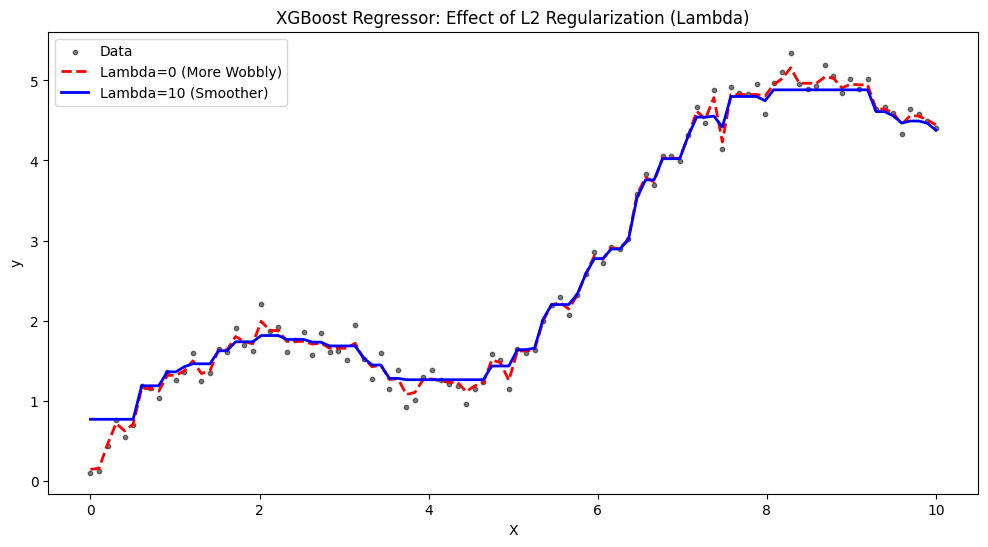

In [5]:
# 4. Plot
plt.figure(figsize=(12, 6))
plt.scatter(X, y, c="k", label="Data", s=10, alpha=0.5)
plt.plot(X, y_loose, c="red", label="Lambda=0 (More Wobbly)", linewidth=2, linestyle='--')
plt.plot(X, y_tight, c="blue", label="Lambda=10 (Smoother)", linewidth=2)
plt.title("XGBoost Regressor: Effect of L2 Regularization (Lambda)")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()